# Matplotlib tutorial

Matplotlib is the standard plotting library for Python.
This notebook shows the kinds of plots you will need in this course.
Run each cell and compare the code with the figure it produces.

## Basic plots

`plt.plot(x, y)` draws a line through the points `(x[i], y[i])`.
Calling it twice draws two lines into the same figure.
In a notebook, the figure appears below the cell.
In a script, end with `plt.show()` to open a window, or with `plt.savefig("figure.pdf")` to write the figure to a file.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Set Matplotlib backend to `inline` to display the figure below the cell that produced it
%matplotlib inline

# Plot sine and cosine over the interval [-2π, 2π]
x = np.linspace(-2 * np.pi, 2 * np.pi, num=100)
sin_x = np.sin(x)
cos_x = np.cos(x)
plt.plot(x, sin_x)
plt.plot(x, cos_x);  # Use `;` to suppress printing of the return value

ModuleNotFoundError: No module named 'matplotlib'

**Hint**: statements starting with `%` or `%%` are IPython *magic functions*, see https://ipython.readthedocs.io/en/stable/interactive/magics.html for more information.

## Labels

A plot without labels is hard to read.
Give each line a `label` and call `plt.legend()` to show them.
Text between dollar signs is typeset as math, so `r"$\sin(x)$"` renders as $\sin(x)$.
Use a raw string (the `r` prefix) whenever the text contains a backslash.

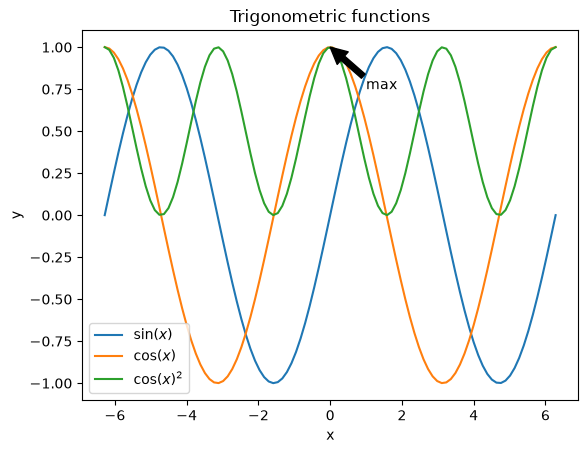

In [2]:
# Strings are rendered as Mathtext when enclosed by `$`
plt.plot(x, sin_x, label=r"$\sin(x)$")
plt.plot(x, cos_x, label=r"$\cos(x)$")
plt.plot(x, cos_x ** 2, label=r"$\cos(x)^2$")

# Show legend
plt.legend()

# Set axis labels
plt.xlabel("x")
plt.ylabel("y")

# Annotate specific data point
plt.annotate(
    "max", xy=(0, 1), xytext=(1, 0.75),
    arrowprops={"facecolor": "black"}
)

# Set title
plt.title("Trigonometric functions");

## Custom style

Almost everything in a plot can be changed: the figure size, the colours, the line styles, the markers, the axis limits, and the grid.
Each of these is a keyword argument or a separate `plt` function.

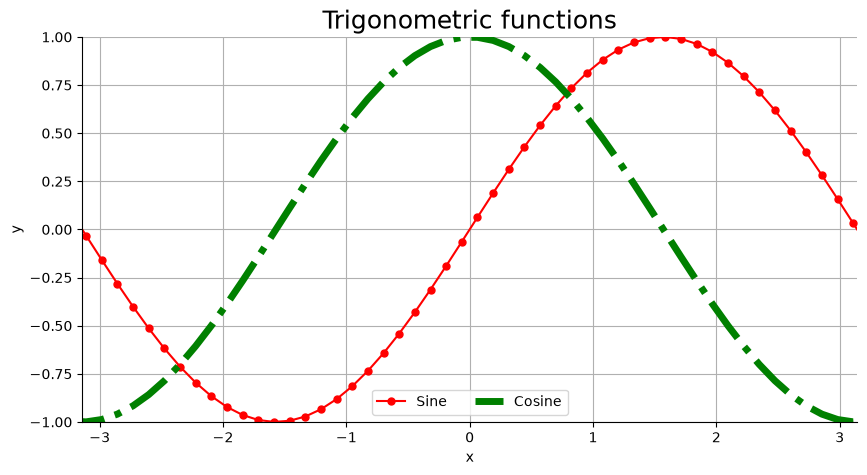

In [3]:
# Set figure size
plt.figure(figsize=(10, 5))

# Set marker, marker size and color
plt.plot(
    x, sin_x, label="Sine",
    marker="o", markersize=5, color="r"
)

# Set line style and width
plt.plot(
    x, cos_x, label="Cosine",
    color="g", linestyle="dashdot", linewidth=5
)

# Set x-axis limits
plt.xlim(-np.pi, np.pi)

# Set y-axis limits
plt.ylim(-1, 1)

# Enable grid lines
plt.grid()

# Hide top and right spines
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Set legend location and number of columns
plt.legend(loc="lower center", ncol=2)
plt.xlabel("x")Plot these functions over the interval :
plt.ylabel("y")

# Change font size
plt.title("Trigonometric functions", fontsize=18);

## Advanced style options

Instead of styling every plot by hand, you can pick a predefined style and change settings globally with the `rc` function.
Here we use the `ggplot` style and a serif font, then switch back to the default.

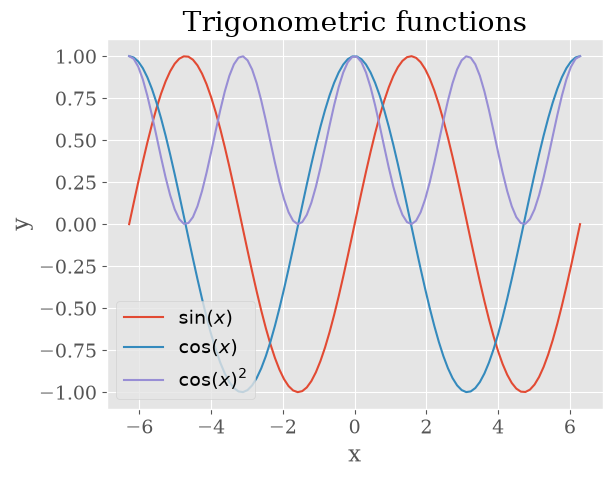

In [4]:
# Use the `rc` function to change rendering options globally
from matplotlib import rc


# Use a different style
plt.style.use("ggplot")

# Change font globally
rc("font", family="serif", size=14)

plt.plot(x, sin_x, label=r"$\sin(x)$")
plt.plot(x, cos_x, label=r"$\cos(x)$")
plt.plot(x, cos_x ** 2, label=r"$\cos(x)^2$")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trigonometric functions")

# Restore default style
plt.style.use("default")

## Multiple subplots

`plt.subplot(rows, columns, index)` splits the figure into a grid and selects one cell of it.
All following `plt` calls draw into that cell.

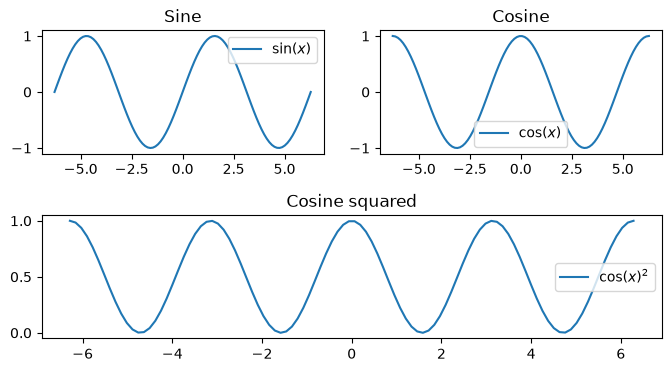

In [5]:
# Create new figure
plt.figure(figsize=(8, 4))

# First subplot
plt.subplot(2, 2, 1)  # Rows, columns, index
plt.plot(x, sin_x, label=r"$\sin(x)$")
plt.legend()
plt.title("Sine")

# Second subplot
plt.subplot(2, 2, 2)
plt.plot(x, cos_x, label=r"$\cos(x)$")
plt.legend()
plt.title("Cosine")

# Third subplot spanning 2 columns
plt.subplot(2, 1, 2)
plt.plot(x, cos_x ** 2, label=r"$\cos(x)^2$")
plt.legend()
plt.title("Cosine squared")

# Fix vertical margin to avoid label overlap
plt.subplots_adjust(hspace=0.5)

## The object-oriented interface

So far we called functions on `plt`.
Each call draws into the "current" axes, which Matplotlib tracks for you.
With several subplots this gets confusing.
The object-oriented interface avoids it.
`plt.subplots(rows, columns)` returns a figure and an array of axes.
You then call methods on the axes you want to draw into.
Some names change: `plt.title` becomes `ax.set_title` and `plt.xlabel` becomes `ax.set_xlabel`, while `ax.plot` and `ax.legend` stay the same.
Both interfaces produce the same figure.
Use the object-oriented one whenever a figure has more than one axes.
Most examples online, and the later labs, use it.

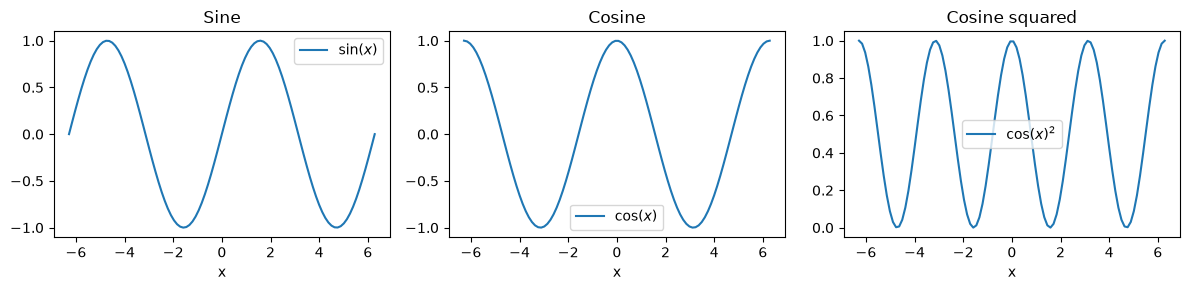

In [6]:
# Create a figure with one row of three axes
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# `axes` is an array; pick the axes to draw into by index
axes[0].plot(x, sin_x, label=r"$\sin(x)$")
axes[0].set_title("Sine")

axes[1].plot(x, cos_x, label=r"$\cos(x)$")
axes[1].set_title("Cosine")

axes[2].plot(x, cos_x ** 2, label=r"$\cos(x)^2$")
axes[2].set_title("Cosine squared")

# Loop over the axes for the settings they share
for ax in axes:
    ax.set_xlabel("x")
    ax.legend()

# Let Matplotlib fix the spacing between the axes
fig.tight_layout()

## Histograms

A histogram counts how many values fall into each bin.
We use the Iris data set: 150 flowers, four measurements per flower, and a species label 0, 1 or 2.
It ships with scikit-learn, so no download is needed.

In [7]:
# Load the Iris data that ships with scikit-learn
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

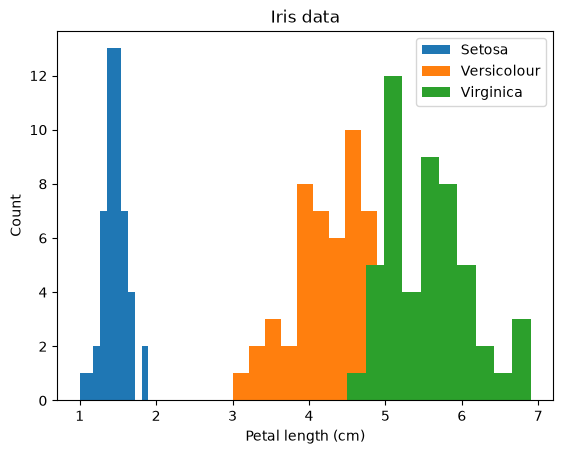

In [8]:
# Plot petal length by class
# 0 <=> "Setosa", 1 <=> "Versicolour", 2 <=> "Virginica"
plt.hist(X[y == 0, 2], label="Setosa")
plt.hist(X[y == 1, 2], label="Versicolour")
plt.hist(X[y == 2, 2], label="Virginica")

plt.legend()
plt.xlabel("Petal length (cm)")
plt.ylabel("Count")
plt.title("Iris data");

## Scatterplots

A scatter plot draws one point per sample.
It is the quickest way to see whether two measurements separate the classes.

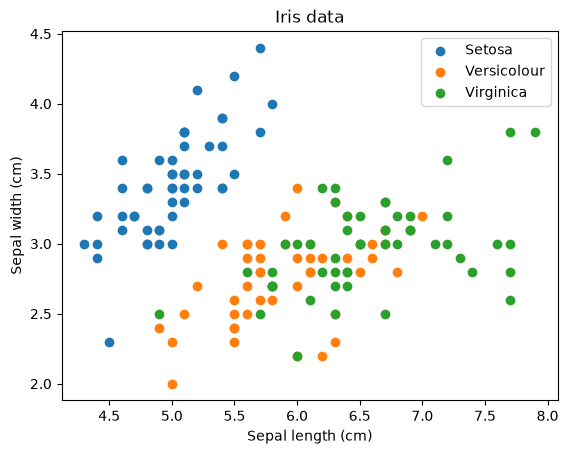

In [9]:
# Plot sepal width vs sepal length by class
# 0 <=> "Setosa", 1 <=> "Versicolour", 2 <=> "Virginica"
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Setosa")
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Versicolour")
plt.scatter(X[y == 2, 0], X[y == 2, 1], label="Virginica")

plt.legend()
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris data");

## Heatmaps

`plt.imshow` shows a matrix as an image, with one colour per entry.
A colour bar maps the colours back to numbers.
The same function displays pictures, which you will need in the assignment.

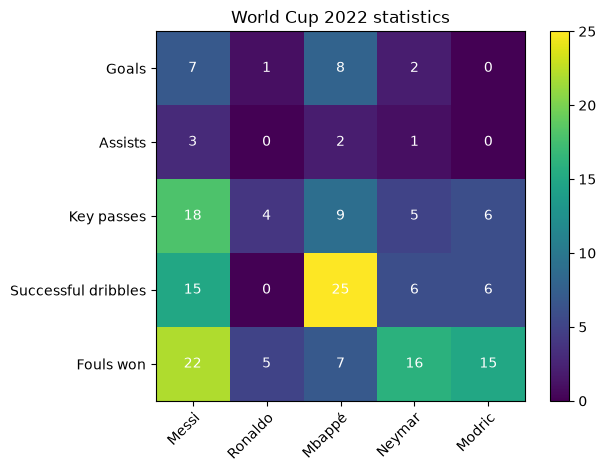

In [10]:
players = ["Messi", "Ronaldo", "Mbappé", "Neymar", "Modric"]
stats = ["Goals", "Assists", "Key passes", "Successful dribbles", "Fouls won"]

data = np.array([
    [7, 1, 8, 2, 0],
    [3, 0, 2, 1, 0],
    [18, 4, 9, 5, 6],
    [15, 0, 25, 6, 6],
    [22, 5, 7, 16, 15],
])

# Plot heatmap
heatmap = plt.imshow(data)

# Create colorbar
plt.colorbar(heatmap)

# Show all ticks and label them with the respective list entries
plt.xticks(np.arange(len(players)), labels=players)
plt.yticks(np.arange(len(stats)), labels=stats)

# Rotate the tick labels and set their alignment
plt.setp(plt.xticks()[1], rotation=45, ha="right", rotation_mode="anchor")

# Loop over data dimensions and create text annotations
for i in range(len(stats)):
    for j in range(len(players)):
        plt.text(j, i, data[i, j], ha="center", va="center", color="w")

plt.title("World Cup 2022 statistics");